# Step 3: Simple Baseline

**Goal:** Establish performance floor with classical methods

**Tasks:**
- [x] Extract hand-crafted features per batch
- [x] Train Ridge regression on source
- [x] Train with cross-validation for more robust estimates
- [x] Analyze regularization strength impact
- [x] Evaluate on source (val) and target (test)
- [x] Report MAE, RMSE

**Contents:**
1. Load Data and Define Splits
2. Train and Evaluate Baseline (Simple Split)
3. Cross-Validation Training
4. **Regularization Analysis**
5. Visualize Predictions
6. Analyze Domain Shift

In [ ]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src.data_loader import load_batches
from src.domain_splits import get_control_mode_split
from src.baseline_model import train_and_evaluate_baseline, RidgeBaseline
from src.feature_config import INPUT_FEATURES_EXPANDED

sns.set_theme(style='whitegrid')
%matplotlib inline

print(f"Using {len(INPUT_FEATURES_EXPANDED)} input features")

In [2]:
window_fraction = 0.9 # fraction of total exp time until crop prediction window

## 1. Load Data and Define Splits

In [3]:
# Load batches
batches = load_batches()
print(f"Loaded {len(batches)} batches")

# Get domain split (1b: Recipe vs APC)
split = get_control_mode_split("1c")
source_ids = split["source"]  # 1-30
target_ids = split["target"]  # 61-90

# Split source into train/val
np.random.seed(123)
source_shuffled = np.random.permutation(source_ids)
n_val = int(len(source_ids) * 0.2)
val_ids = list(source_shuffled[:n_val])
train_ids = list(source_shuffled[n_val:])

print(f"Train: {len(train_ids)} batches")
print(f"Val: {len(val_ids)} batches")
print(f"Target: {len(target_ids)} batches")

Loaded 100 batches
Train: 48 batches
Val: 12 batches
Target: 30 batches


## 2. Train and Evaluate Baseline

In [4]:
# Train baseline model
results = train_and_evaluate_baseline(
    batches,
    train_ids=train_ids,
    val_ids=val_ids,
    target_ids=target_ids,
    alpha=500.0,
    window_fraction=window_fraction,
)

print("Baseline Results (Ridge Regression)")
print("=" * 40)
# Create metrics table
metrics_df = pd.DataFrame({
    "Split": ["Train (Source)", "Val (Source)", "Target"],
    "MAE": [
        results["train"]["mae"],
        results["val"]["mae"],
        results["target"]["mae"],
    ],
    "RMSE": [
        results["train"]["rmse"],
        results["val"]["rmse"],
        results["target"]["rmse"],
    ],
})
metrics_df = metrics_df.round(3)
print(metrics_df.to_string(index=False))

# Save metrics
metrics_df.to_csv("../outputs/baseline_metrics.csv", index=False)
print("\nSaved to outputs/baseline_metrics.csv")

Baseline Results (Ridge Regression)
         Split   MAE  RMSE
Train (Source) 4.795 5.608
  Val (Source) 4.443 5.157
        Target 3.707 4.385

Saved to outputs/baseline_metrics.csv


## 3. Cross-Validation Training

Cross-validation provides more robust performance estimates by using all source data for both training and validation.

In [5]:
# Train Ridge with 5-fold cross-validation on all source data
ridge_cv = RidgeBaseline()
cv_results = ridge_cv.fit_cv(
    batches,
    train_ids=source_ids,  # Use all source data for CV
    n_folds=5,
    alphas=500,  # Tune alpha
    window_fraction=window_fraction,
    random_state=42,
)

print("Cross-Validation Results (5-fold)")
print("=" * 50)
print(f"CV MAE:  {cv_results['cv_mae']:.3f}")
print(f"CV RMSE: {cv_results['cv_rmse']:.3f}")
print(f"Best Alpha: {cv_results['best_alpha']}")
print()

# Per-fold metrics
fold_df = pd.DataFrame(cv_results['fold_metrics'])
print("Per-Fold Results:")
print(fold_df.round(3).to_string(index=False))
print()
print(f"MAE: {fold_df['mae'].mean():.3f} +/- {fold_df['mae'].std():.3f}")

Cross-Validation Results (5-fold)
CV MAE:  5.042
CV RMSE: 6.002
Best Alpha: 500.0

Per-Fold Results:
 fold   mae  rmse  n_train  n_val  best_alpha
    1 4.393 4.847       48     12       500.0
    2 4.986 6.134       48     12       500.0
    3 4.969 5.684       48     12       500.0
    4 5.758 6.452       48     12       500.0
    5 5.103 6.712       48     12       500.0

MAE: 5.042 +/- 0.486


## 4. Regularization Analysis

Evaluate how different regularization strengths (alpha) affect model performance. Higher alpha values increase regularization, reducing model complexity and potentially improving generalization.

In [6]:
# Evaluate Ridge with progressive regularization strengths
alphas = np.logspace(-1,5,100)

regularization_results = []
for alpha in alphas:
    # Train with CV for each alpha
    ridge_alpha = RidgeBaseline(alpha=alpha)
    cv_res = ridge_alpha.fit_cv(
        batches,
        train_ids=source_ids,
        n_folds=5,
        alphas=None,  # Use fixed alpha, no tuning
        window_fraction=window_fraction,
        random_state=42,
    )
    
    # Evaluate on target
    target_res = ridge_alpha.evaluate(batches, target_ids)
    
    regularization_results.append({
        "alpha": alpha,
        "cv_mae": cv_res["cv_mae"],
        "cv_rmse": cv_res["cv_rmse"],
        "cv_mae_std": pd.DataFrame(cv_res["fold_metrics"])["mae"].std(),
        "target_mae": target_res["mae"],
        "target_rmse": target_res["rmse"],
        "gap": target_res["mae"] - cv_res["cv_mae"],
    })

reg_df = pd.DataFrame(regularization_results)
print("Regularization Analysis (5-fold CV)")
print("=" * 80)
print(reg_df.round(3).to_string(index=False))
print()

# Find optimal alpha
best_cv_idx = reg_df["cv_mae"].idxmin()
best_target_idx = reg_df["target_mae"].idxmin()
print(f"Best alpha for CV MAE: {reg_df.loc[best_cv_idx, 'alpha']} (CV MAE = {reg_df.loc[best_cv_idx, 'cv_mae']:.3f})")
print(f"Best alpha for Target MAE: {reg_df.loc[best_target_idx, 'alpha']} (Target MAE = {reg_df.loc[best_target_idx, 'target_mae']:.3f})")

Regularization Analysis (5-fold CV)
     alpha  cv_mae  cv_rmse  cv_mae_std  target_mae  target_rmse    gap
     0.100   3.666    4.569       0.537      28.684       29.647 25.018
     0.115   3.614    4.502       0.517      27.252       28.231 23.638
     0.132   3.558    4.436       0.503      25.861       26.860 22.304
     0.152   3.502    4.371       0.490      24.521       25.541 21.020
     0.175   3.443    4.307       0.483      23.239       24.281 19.796
     0.201   3.386    4.244       0.477      22.016       23.083 18.630
     0.231   3.328    4.182       0.474      20.855       21.947 17.526
     0.266   3.280    4.121       0.468      19.753       20.873 16.473
     0.305   3.232    4.062       0.465      18.708       19.857 15.476
     0.351   3.186    4.004       0.461      17.714       18.893 14.528
     0.404   3.138    3.948       0.460      16.766       17.978 13.628
     0.464   3.092    3.894       0.459      15.859       17.105 12.767
     0.534   3.047    3.841 

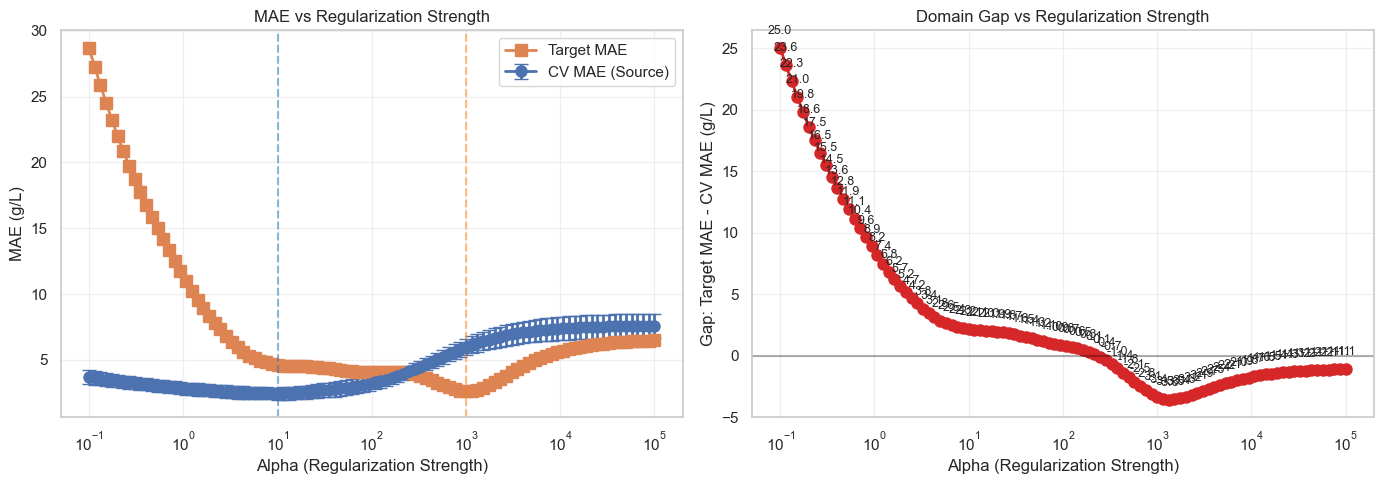

Saved to outputs/figures/baseline_regularization.png


In [7]:
# Visualize regularization effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: MAE vs Alpha (log scale)
ax = axes[0]
ax.errorbar(reg_df["alpha"], reg_df["cv_mae"], yerr=reg_df["cv_mae_std"], 
            marker='o', capsize=5, label='CV MAE (Source)', linewidth=2, markersize=8)
ax.plot(reg_df["alpha"], reg_df["target_mae"], 
        marker='s', label='Target MAE', linewidth=2, markersize=8)
ax.set_xscale('log')
ax.set_xlabel('Alpha (Regularization Strength)')
ax.set_ylabel('MAE (g/L)')
ax.set_title('MAE vs Regularization Strength')
ax.legend()
ax.grid(True, alpha=0.3)

# Mark optimal points
best_cv_alpha = reg_df.loc[reg_df["cv_mae"].idxmin(), "alpha"]
best_target_alpha = reg_df.loc[reg_df["target_mae"].idxmin(), "alpha"]
ax.axvline(best_cv_alpha, color='tab:blue', linestyle='--', alpha=0.5, label=f'Best CV α={best_cv_alpha}')
ax.axvline(best_target_alpha, color='tab:orange', linestyle='--', alpha=0.5, label=f'Best Target α={best_target_alpha}')

# Plot 2: Domain Gap vs Alpha
ax = axes[1]
ax.plot(reg_df["alpha"], reg_df["gap"], marker='o', linewidth=2, markersize=8, color='tab:red')
ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.set_xscale('log')
ax.set_xlabel('Alpha (Regularization Strength)')
ax.set_ylabel('Gap: Target MAE - CV MAE (g/L)')
ax.set_title('Domain Gap vs Regularization Strength')
ax.grid(True, alpha=0.3)

# Annotate
for i, row in reg_df.iterrows():
    ax.annotate(f'{row["gap"]:.1f}', (row["alpha"], row["gap"]), 
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/baseline_regularization.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/figures/baseline_regularization.png")

## 5. Visualize Predictions

Compare predicted vs actual final penicillin concentration across train, validation, and target sets.

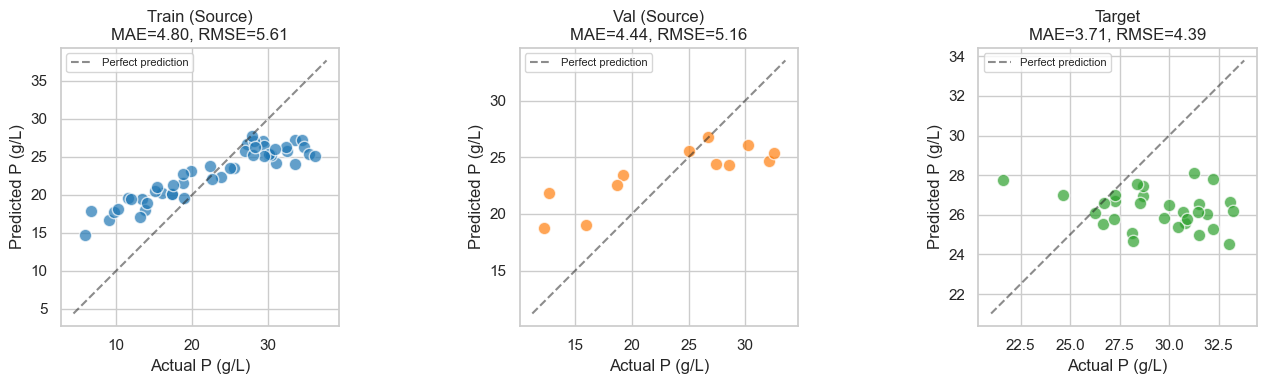

Saved to outputs/figures/baseline_predictions.png


In [9]:
# Plot predictions vs actuals for all splits
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

splits_data = [
    ("Train (Source)", results["train"], train_ids, "tab:blue"),
    ("Val (Source)", results["val"], val_ids, "tab:orange"),
    ("Target", results["target"], target_ids, "tab:green"),
]

for ax, (title, res, batch_ids, color) in zip(axes, splits_data):
    y_true = res["y_true"]
    y_pred = res["y_pred"]
    
    # Scatter plot
    ax.scatter(y_true, y_pred, alpha=0.7, color=color, edgecolor='white', s=80)
    
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    margin = (max_val - min_val) * 0.05
    ax.plot([min_val - margin, max_val + margin], 
            [min_val - margin, max_val + margin], 
            'k--', alpha=0.5, label='Perfect prediction')
    
    ax.set_xlabel("Actual P (g/L)")
    ax.set_ylabel("Predicted P (g/L)")
    ax.set_title(f"{title}\nMAE={res['mae']:.2f}, RMSE={res['rmse']:.2f}")
    ax.set_aspect('equal', 'box')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/figures/baseline_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/figures/baseline_predictions.png")

## 6. Analyze Domain Shift

In [10]:
# Compare performance gap
val_mae = results["val"]["mae"]
target_mae = results["target"]["mae"]
gap = target_mae - val_mae
gap_pct = (gap / val_mae) * 100

print(f"Source Val MAE: {val_mae:.3f}")
print(f"Target MAE: {target_mae:.3f}")
print(f"Performance Gap: {gap:.3f} ({gap_pct:+.1f}%)")
print()
if gap > 0:
    print("Domain shift detected: Model performs worse on target domain.")
else:
    print("No significant domain shift observed.")

Source Val MAE: 4.443
Target MAE: 3.707
Performance Gap: -0.736 (-16.6%)

No significant domain shift observed.


## Summary

**Ridge Regression Baseline:**
- Uses hand-crafted features (mean, std, min, max, slope) from early window (25%)
- Trained on source domain only (e.g., Recipe batches 1-30)
- Evaluated on source validation and target domain (e.g., APC batches 61-90)

**Key Observations:**
- Model fits reasonably well in training set but on validation does poorly - domain shift not so significant
- Performance gap between source and target indicates domain shift
- This baseline establishes the performance floor for comparison with transformer models